
## Why we need SVM?
It is mainy used for
 -complex data separation
 -classification problem
 -binary classification
Ex:spam vs not spam
   cat vs dog
   disease vs no disease

## Problem with logistic regression?
 logistic regression works well when data is linearly separable but what if
  -data is complex
  -classes overlap
  -decision boundary is 
  that is where svm becomes powerful

linear regression
 y=mx+c
 m-slope,c-intercept are the parameters which learn from data

#### Parameters- the values which learn form the data
#### Hyperparameter- the parametes which are not related to the data,not dependent on the the data
     -these are the input parameters which we pass to the model
     -for each and every algorithm, hyperparamters will change
     -to check hyperparamaters(which suits the best)-grid searchCV and randomized searchCV
#### Diff btw grid and randomized?
     -GridSearchCV evaluates every possible combination, while RandomizedSearchCV samples a fixed number of random combinations from specified distributions.
     -GridSearchCV is best because it takes the best combinations and less time
     -RandomizedSearchCV takes possible combinations but not best and takes more time





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('medical_Diagnosis_dataset.csv')
df.head()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0,Former
1,-1.930636,-0.406752,3.061308,1.083145,-2.934634,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,Smoker
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,Non-smoker
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,Non-smoker
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,Non-smoker


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   glucose_level   1000 non-null   float64
 1   blood_pressure  1000 non-null   float64
 2   cholesterol     1000 non-null   float64
 3   bmi             1000 non-null   float64
 4   age             1000 non-null   float64
 5   feature_6       1000 non-null   float64
 6   feature_7       1000 non-null   float64
 7   feature_8       1000 non-null   float64
 8   feature_9       1000 non-null   float64
 9   feature_10      1000 non-null   float64
 10  target          1000 non-null   int64  
 11  smoking_status  1000 non-null   object 
dtypes: float64(10), int64(1), object(1)
memory usage: 93.9+ KB


In [3]:
df.describe()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.987192,0.049559,-0.048558,-0.006647,-0.760523,1.876671,-0.024828,0.034693,0.926480,-0.760954,0.106000
std,0.945743,1.541166,1.711178,0.966008,1.769060,2.217174,1.052177,1.821284,2.070509,1.681686,0.307992
min,-4.247963,-5.446468,-5.558615,-3.688365,-7.844223,-5.639699,-3.221016,-6.274085,-5.495407,-6.626081,0.000000
25%,-1.586288,-0.941598,-1.259443,-0.608662,-2.043784,0.385351,-0.737644,-1.176866,-0.445276,-1.850878,0.000000
50%,-0.987192,0.106014,0.033210,-0.006647,-0.734590,2.047293,-0.060376,0.108569,0.708714,-0.743577,0.000000
75%,-0.432312,1.066150,1.194692,0.603761,0.436495,3.477828,0.730339,1.252404,2.174464,0.357380,0.000000
max,2.695232,4.604960,4.584841,3.529055,5.466089,8.254264,2.943048,5.066045,8.263826,5.379806,1.000000


In [4]:
df

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0,Former
1,-1.930636,-0.406752,3.061308,1.083145,-2.934634,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,Smoker
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,Non-smoker
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,Non-smoker
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,Non-smoker
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.326662,0.667346,-1.258075,-1.075737,-1.266081,1.746493,-0.528998,-2.528915,-0.244415,-1.203668,0,Former
996,0.075206,0.198699,1.878295,-1.007868,-1.424495,-1.149712,-0.608494,1.537761,2.524093,0.864625,0,Smoker
997,-2.728454,-0.352948,1.461926,1.127686,-3.808356,6.246633,0.958816,0.233868,4.350736,-3.104087,0,Non-smoker
998,-0.987192,1.676627,-0.235451,-0.006647,-0.408889,1.080665,-0.157025,2.201371,-0.727689,-1.082463,0,Former


In [5]:
df.isnull().sum()

glucose_level     0
blood_pressure    0
cholesterol       0
bmi               0
age               0
feature_6         0
feature_7         0
feature_8         0
feature_9         0
feature_10        0
target            0
smoking_status    0
dtype: int64

In [6]:
# Convert to Realistic Age
df['age'] = (df['age']-df['age'].min()) / (df['age'].max() - df['age'].min())

# range between to 18 and 80
df['age'] = df['age'] * (80 - 18) + 18

# convert to integer
df['age'] = df['age'].astype(int)
df.head()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status
0,-1.030931,1.391626,0.547274,0.928932,46,1.250002,1.332551,1.578256,2.124722,-0.318434,0,Former
1,-1.930636,-0.406752,3.061308,1.083145,40,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,Smoker
2,-0.558987,0.299849,1.527071,0.360442,48,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,Non-smoker
3,-1.350289,-2.046078,-0.614264,0.126459,50,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,Non-smoker
4,-0.275754,-0.728495,0.027727,-0.660834,45,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,Non-smoker


In [7]:
# handle categorical variables
df = pd.get_dummies(df)
df.head()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status_Former,smoking_status_Non-smoker,smoking_status_Smoker
0,-1.030931,1.391626,0.547274,0.928932,46,1.250002,1.332551,1.578256,2.124722,-0.318434,0,True,False,False
1,-1.930636,-0.406752,3.061308,1.083145,40,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,False,False,True
2,-0.558987,0.299849,1.527071,0.360442,48,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,False,True,False
3,-1.350289,-2.046078,-0.614264,0.126459,50,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,False,True,False
4,-0.275754,-0.728495,0.027727,-0.660834,45,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,False,True,False


In [8]:
# convert smoking_status_Former	smoking_status_Non-smoker	smoking_status_Smoker into integer values
df['smoking_status_Former'] = df['smoking_status_Former'].astype(int)
df['smoking_status_Non-smoker'] = df['smoking_status_Non-smoker'].astype(int)
df['smoking_status_Smoker'] = df['smoking_status_Smoker'].astype(int)

In [9]:
df.dtypes

glucose_level                float64
blood_pressure               float64
cholesterol                  float64
bmi                          float64
age                            int64
feature_6                    float64
feature_7                    float64
feature_8                    float64
feature_9                    float64
feature_10                   float64
target                         int64
smoking_status_Former          int64
smoking_status_Non-smoker      int64
smoking_status_Smoker          int64
dtype: object

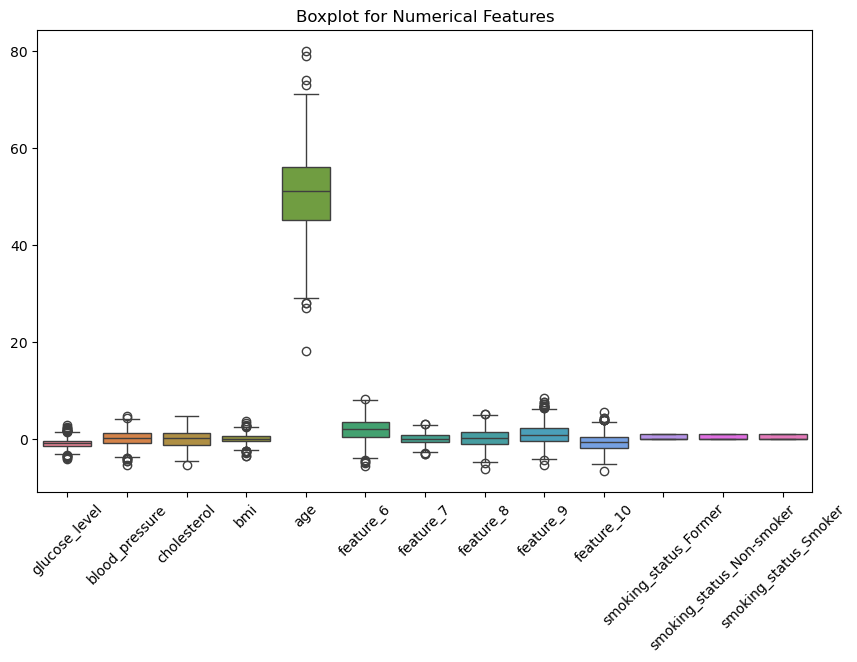

In [10]:
# Outliers detection using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('target', axis=1))
plt.title('Boxplot for Numerical Features')
plt.xticks(rotation=45)
plt.show()

In [11]:
# clip the outliers for all columns except the target column
for column in df.columns:
    if column != 'target':
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

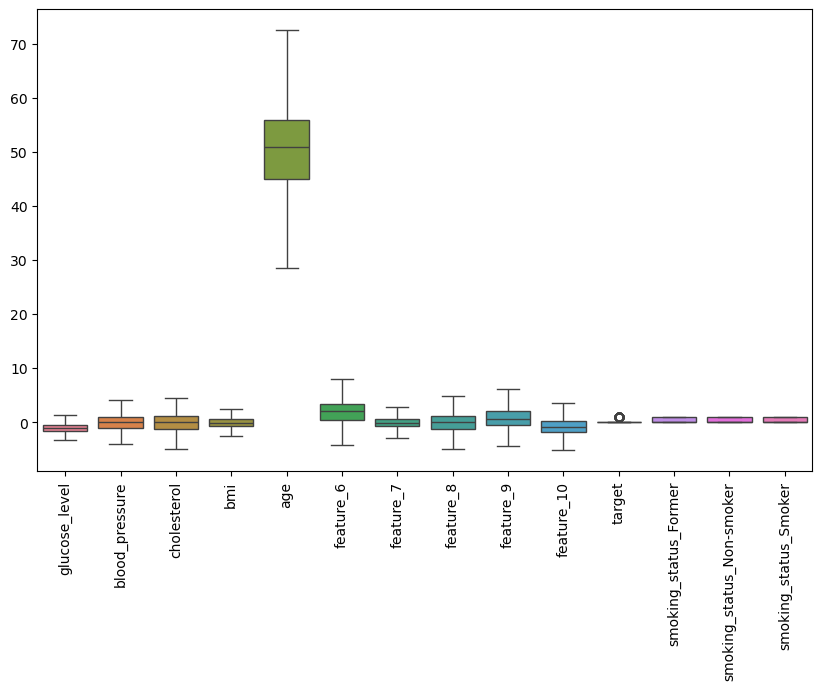

In [12]:
# box plot to check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [13]:
# check value counts for target variable
df['target'].value_counts()

target
0    894
1    106
Name: count, dtype: int64

In [14]:
# separate features and target variable
X = df.drop('target', axis=1)
y = df['target']

print(X.shape)
print(y.shape)

(1000, 13)
(1000,)


In [15]:
# test train split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 13)
(200, 13)
(800,)
(200,)


In [16]:
# Create an SVM model
from sklearn.svm import SVC

svm_classifier = SVC(kernel='rbf', #Type of boundry
                    C=1.0, # Regularization parameter
                    gamma='scale' # controls the influence of data points on the decision boundary
                    )

In [17]:
# Create an SVM model
from sklearn.svm import SVC

svm_classifier = SVC(kernel='rbf', #Type of boundry
                    C=1.0, # Regularization parameter
                    gamma='scale',# controls the influence of data points on the decision boundary
                    class_weight='balanced', # Adjust weights inversely proportional to class frequencies
                    degree=3,
                    random_state=42,
                    shrinking=True,
                    probability=True,
                    verbose=False,
                    cache_size=200
                    )

In [18]:
# Train the model
svm_classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [19]:
# Make predictions
y_pred = svm_classifier.predict(X_test)

In [20]:
# Evaluate the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.74


## Kernels
 #### linear - linear data
 #### ploynomial - polynomial relationship
 ##### rbf - non linear complex data
 ##### sigmoid - neural network like behaviour

#### c = 1
#### controls overfitting vs underfitting
#### small c-->wide margin-->overfitting
#### large c-->tries to classify all points-->may overfit

gamma = scale
controls how far the influence 